### 工作進度  
* 【置頂】**筆記內容架構**與**量化技術分析系統**相關資訊請參閱[260315筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/260315%E7%AD%86%E8%A8%98.ipynb)之「工作進度」。  

* 引入模組與定義公用函式  

In [ ]:
import numpy as np
import mysys
import markdown
from IPython.core.display import HTML

In [ ]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

* 更新量化技術分析資料庫  

In [ ]:
mysys.UpdateStockDatabase()

* 建立「解盤」物件    

In [ ]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股篩選  

* 選股程序    

In [ ]:
results = analysis.screener()

In [ ]:
for stock_info in results :
    print('股票代碼 ＝ {} ， 股票名稱 ＝ {} '.format(stock_info[0],stock_info[1]))

* 篩選結果  
  -  光鋐(4956)：多頭回檔  
     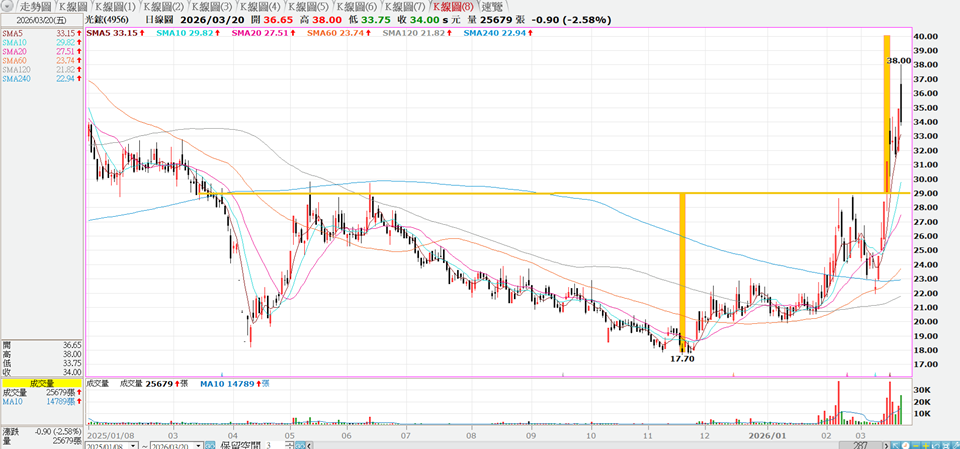  
  -  映泰(2399)：強勢多頭  
     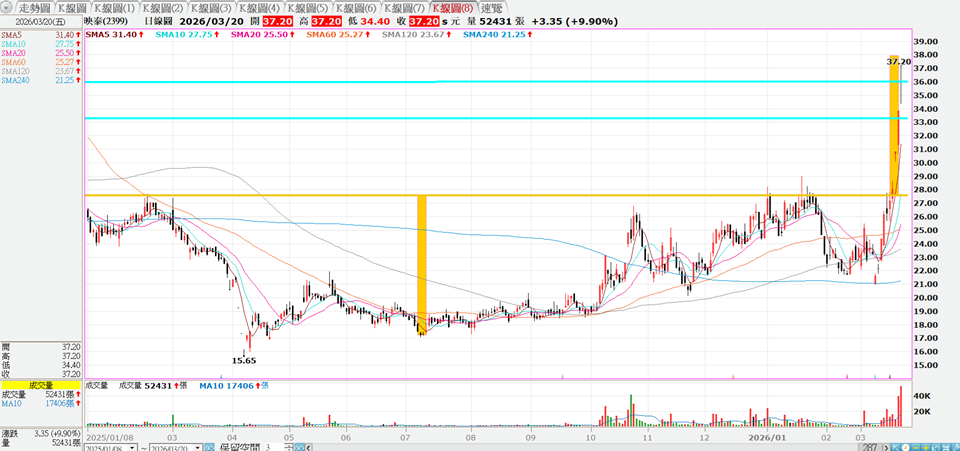  
  -  李洲(3066)：多頭回檔  
     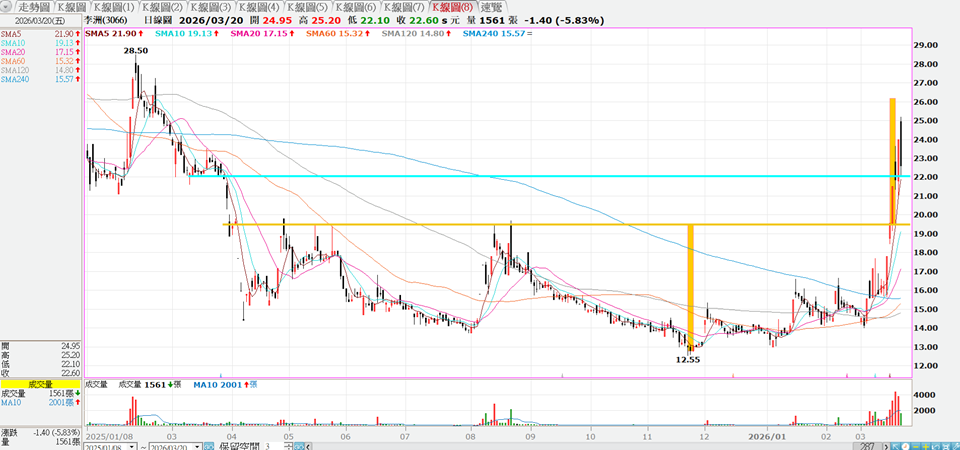  
  -  華夏(1305)：穩健續漲  
     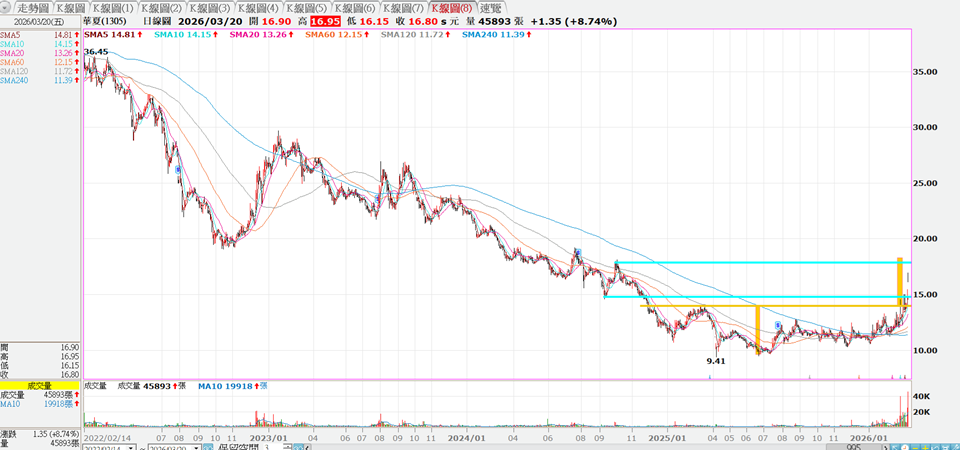  
  -  億光(2393)：已到壓力區  
     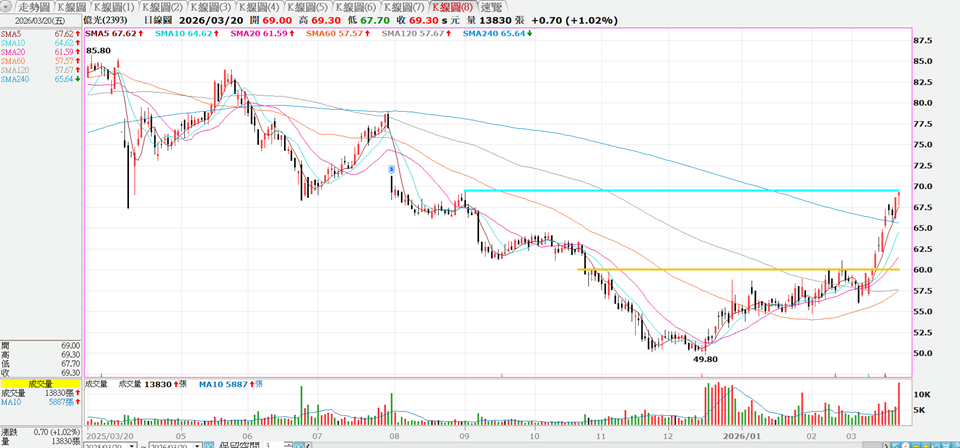  
  -  精元(2387)：盤整觀察  
     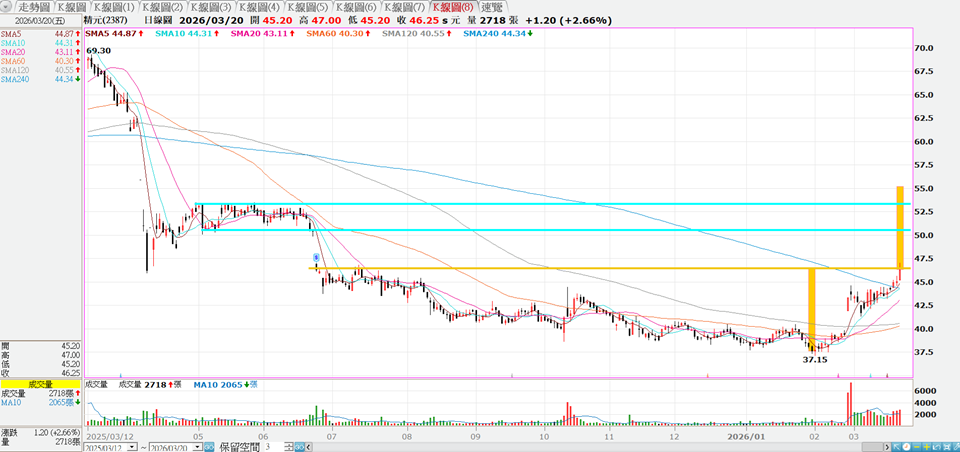  
  -  東聯(1710)：穩健續漲  
     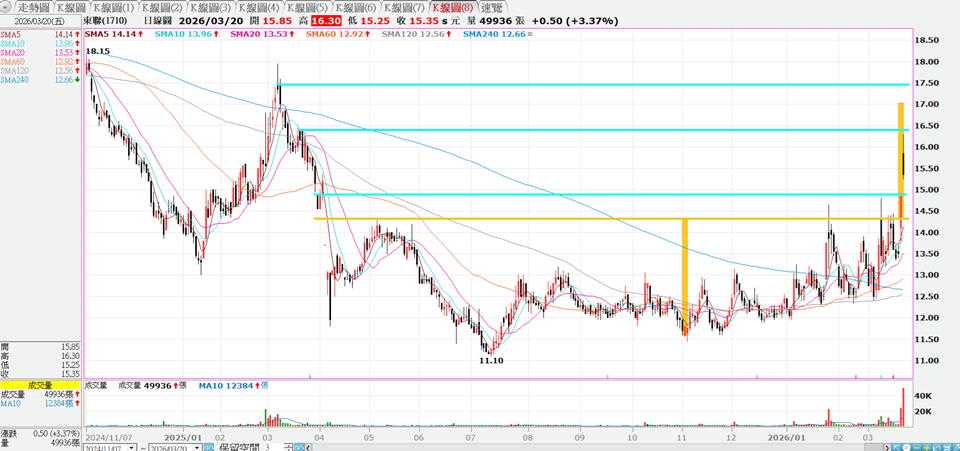  
  -  亞聚(1308)：穩健續漲  
     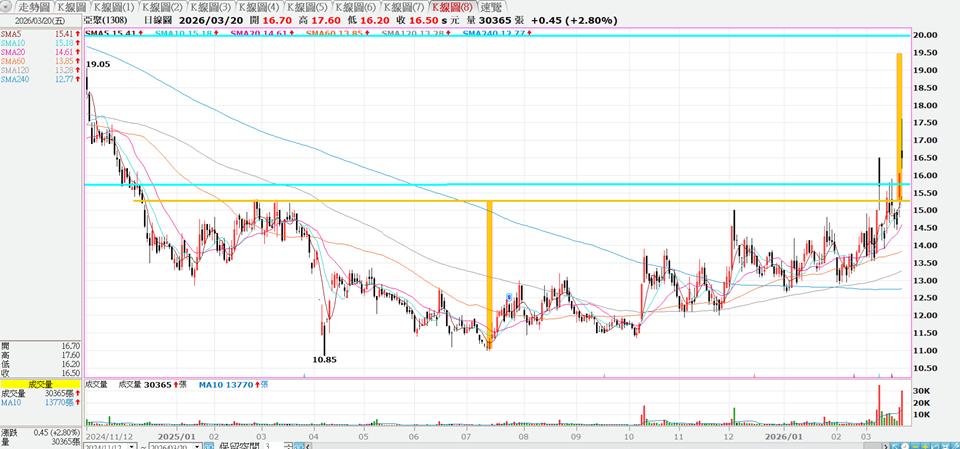  
  -  台聚(1304)：穩健續漲  
     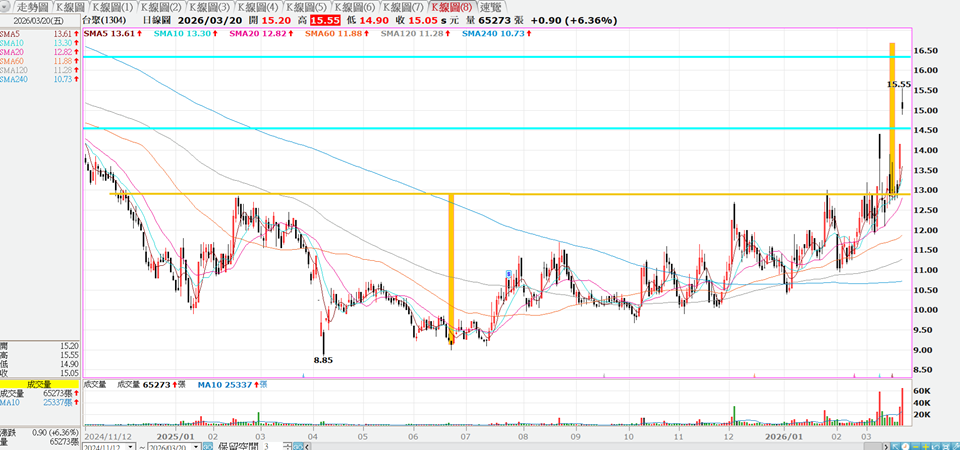        
  -  協禧(3071)：技術突破  
     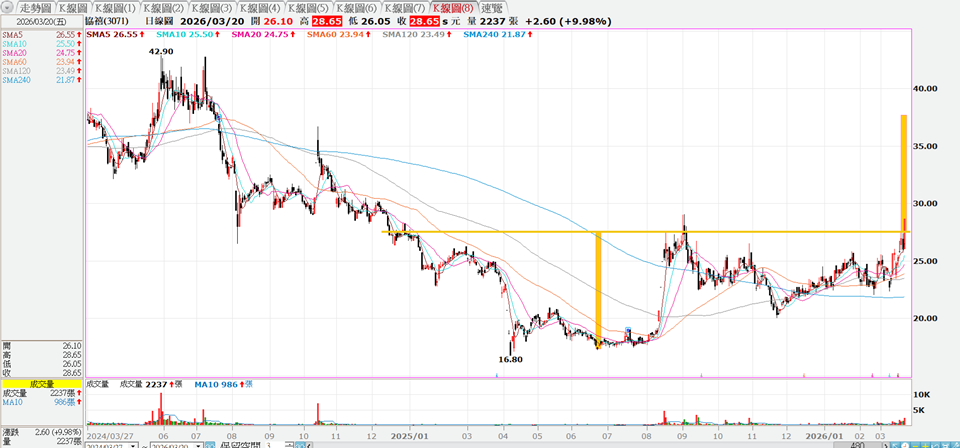  
  -  中鋼構(2013)：盤整觀察  
     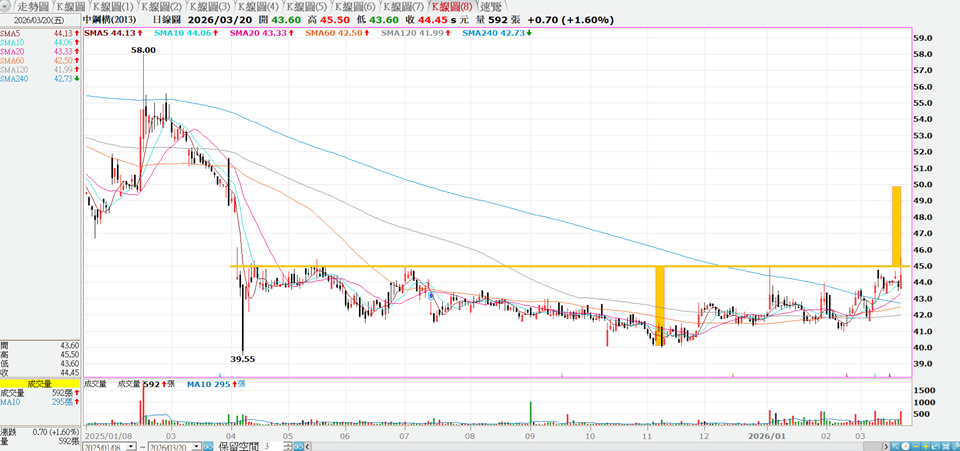  
  -  正文(4906)：已到目標價  
     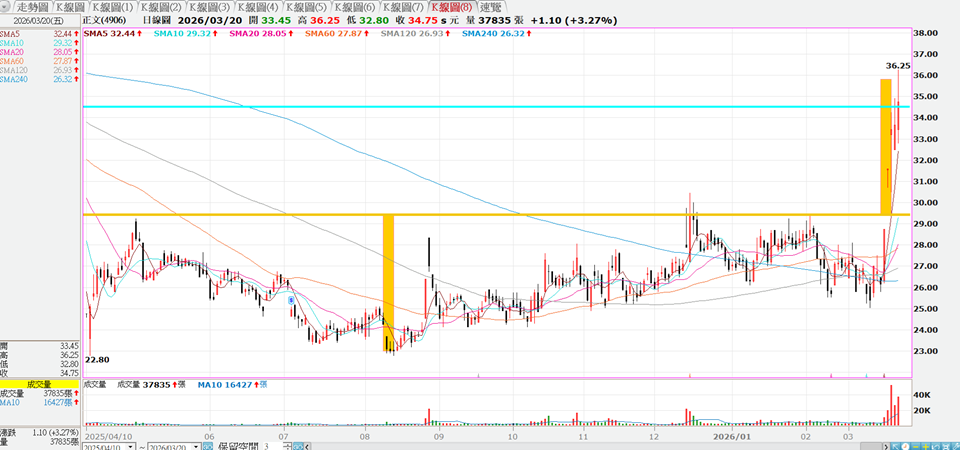  

* 觀察股列表  
  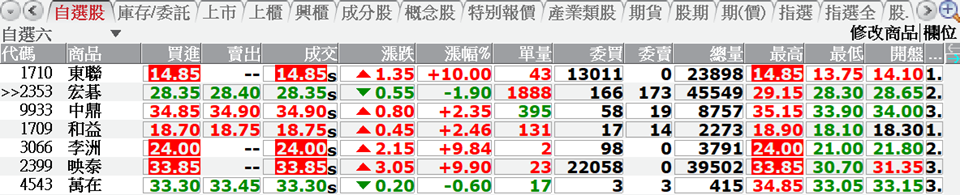  

### 個股解盤  

* 大成(1210)  
  看法：有中期底形雛形，仍在打底中。     

> **盤後**：量化技術分析   

In [ ]:
stock_analysis(analysis,'1210')

> **盤後**：底部反轉交易策略分析   

In [ ]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-10-23'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-11-10']['Open']

    # 設定底部日期與價格
    bottom_date  = '2026-03-04'
    bottom_price = range_prices.loc['2026-03-04']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)]
    ]

    linewidths=[2.0,10.0,10.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

In [ ]:
image = mysys.DrawOnKlineChart('1210','2025-10-09','2026-03-19',line_drawing_callback)
display(image)

籌碼面：  
法人○○( )：外資○○( )、投信○○( )、自營○○( )。  
主力○○( )。  
分公司買賣家數差○○( )。  
融資○○( )、融券○○( )。  

* 宏碁(2353)   
  看法：略跌破頸線支撐，因此這檔觀察至今日。      

> **盤後**：量化技術分析  

In [ ]:
stock_analysis(analysis,'2353')

> **盤後**：底部反轉交易策略分析  

In [ ]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-11-17'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-12-04']['Open']

    # 設定底部日期與價格
    bottom_date  = '2026-01-30'
    bottom_price = range_prices.loc['2026-01-30']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    # 設定突破日期
    breakout_date = '2026-03-18'
    
    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(breakout_date,neckline_price),(breakout_date,target_price)]
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

In [ ]:
image = mysys.DrawOnKlineChart('2353','2025-10-14','2026-03-19',line_drawing_callback)
display(image)

籌碼面：  
法人○○( )：外資○○( )、投信○○( )、自營○○( )。  
主力○○( )。  
分公司買賣家數差○○( )。  
融資○○( )、融券○○( )。  

In [ ]:
# 解盤物件清除
analysis = None

### 技術開發  

試作基於[AI Agent](https://en.wikipedia.org/wiki/AI_agent)技術之全AI解盤程序，這部份僅用於概念驗證。  

In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import sqlite3
import io
import base64
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import markdown

import json

from talib.abstract import *
from dotenv import load_dotenv, find_dotenv
from PIL import Image
from IPython.core.display import HTML

from typing import Any, Dict, List, Optional, Tuple
from openai import OpenAI

In [ ]:
##### 【公用函式】 來源 ： https://www.cnblogs.com/Rosaany/p/15561918.html #####
def get_monday_to_sunday(today, weekly=0):
    last = weekly * 7
    today = datetime.datetime.strptime(str(today), "%Y-%m-%d")
    monday = datetime.datetime.strftime(today - datetime.timedelta(today.weekday() - last), "%Y-%m-%d")
    monday_ = datetime.datetime.strptime(monday, "%Y-%m-%d")
    sunday = datetime.datetime.strftime(monday_ + datetime.timedelta(monday_.weekday() + 6), "%Y-%m-%d")
    return monday, sunday

###### 【內部函式】 當日Ｋ價格資料為零時之修正函式 ######
def correcting_zero_price_issue( daily_price_df, debug = False) :
    # 開啟寫時複製(Copy-on-Write)
    copy_on_write = pd.options.mode.copy_on_write
    pd.options.mode.copy_on_write = True
    
    # 找出開盤價、最高價、收盤價與最低價皆為0的價格資料
    zero_prices_df =  daily_price_df[(daily_price_df['Open'] == 0.0) & (daily_price_df['High'] == 0.0) & (daily_price_df['Low'] == 0.0) & (daily_price_df['Close'] == 0.0)]
    if zero_prices_df.empty is False :
        zero_prices_idx = zero_prices_df.index
        df_first_idx    = daily_price_df.iloc[0].name
        for idx in zero_prices_idx :
            if (idx - 1) >= df_first_idx :
                # 當開盤價、最高價、收盤價與最低價皆為0時，會用前一個交易日的收盤價來做修正
                prev_close_price = daily_price_df.loc[idx-1]['Close']
                prev_stock_id    = daily_price_df.loc[idx-1]['StockID']
                curr_stock_id    = daily_price_df.loc[idx]['StockID']
                if debug is True :
                    print('ＤＥＢＵＧ ： 〈代碼：{}，日期：{}〉  修改前：開 ＝ {} 高 ＝ {} 低 ＝ {} 收 ＝ {}'.format(curr_stock_id,daily_price_df.loc[idx]['Date'],daily_price_df.loc[idx,'Open'],daily_price_df.loc[idx,'High'],daily_price_df.loc[idx,'Low'],daily_price_df.loc[idx,'Close']), end='')
                daily_price_df.loc[idx,'Open']  = prev_close_price
                daily_price_df.loc[idx,'High']  = prev_close_price
                daily_price_df.loc[idx,'Low']   = prev_close_price
                daily_price_df.loc[idx,'Close'] = prev_close_price
                if debug is True :
                    print(' ， 修改後：開 ＝ {} 高 ＝ {} 低 ＝ {} 收 ＝ {}'.format(daily_price_df.loc[idx,'Open'],daily_price_df.loc[idx,'High'],daily_price_df.loc[idx,'Low'],daily_price_df.loc[idx,'Close']))
            else :
                pass
    
    # 還原初始狀態
    pd.options.mode.copy_on_write = copy_on_write

###### 【公用函式】 來源 ： https://stackoverflow.com/questions/73604477/i-am-trying-to-crop-an-image-to-remove-extra-space-in-python #####
def get_first_last(mask, axis: int):
    """ Find the first and last index of non-zero values along an axis in `mask` """
    mask_axis = np.argmax(mask, axis=axis) > 0
    a = np.argmax(mask_axis)
    b = len(mask_axis) - np.argmax(mask_axis[::-1])
    return int(a), int(b)

def crop_borders(img, crop_color):
    np_img = np.array(img)
    mask = (np_img != crop_color)[..., 0]   # compute a mask
    x0, x1 = get_first_last(mask, 0)        # find boundaries along x axis
    y0, y1 = get_first_last(mask, 1)        # find boundaries along y axis
    return img.crop((x0, y0, x1, y1)) 

def result_to_dataframe(result: dict) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "解盤內容": result
        }
    )
    df.index.name = "技術分析工具"
    return df
def display_result( result) :
    result_df = result_to_dataframe( result)
    result_md   = result_df.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

In [ ]:
import json
from typing import Any, Dict, Optional, Tuple
from openai import OpenAI


# =========================
# PROMPT BUILDERS
# =========================

def build_system_prompt(instrument: dict) -> str:
    return f"""
你是一位技術分析師，使用「看圖優先」。

【核心原則】
- 由長到短（長→中→短）
- 最終必須整合成單一結論
- 不可暴露技術欄位名稱
- 型態可以不存在，不可硬湊

【MACD輸出規範】
只允許：DIF線、MACD線、OSC柱體
禁止：macd / macdsignal / 訊號線

【標的】
{json.dumps(instrument, ensure_ascii=False)}
"""


def build_phase1_prompt(stock_id: str) -> str:
    return f"""
你會收到三張圖：
1. 長週期（240）
2. 中週期（120）
3. 短週期（60）

請由長→中→短分析。

--------------------------------------------------

【型態規則】

- 無明確型態 → structure_type = none
- 可用 price_state 描述（narrow_range / high_level_consolidation...）
- 不可硬判型態

--------------------------------------------------

【支撐壓力規則（重要）】

- 支撐與壓力必須來自：
  - 明確高低點（swing high / low）
  - 均線
  - 區間上下緣

- 若不清楚，不可猜測

--------------------------------------------------

【KD判讀與資料需求規則（重要）】

- KD子圖上有兩條綠線，代表超買區與超賣區的區隔

請依以下原則判斷：

1. 若能從圖上清楚判斷：
   - KD已進入超買區（高於上方綠線）
   - 或KD已進入超賣區（低於下方綠線）
   → 可直接判讀，不需要額外資料

2. 若無法明確判斷（例如接近邊界、圖形模糊）：
   → 不可主觀判定
   → 必須設定：
     "need_price_data": "YES"

3. 若KD位置會影響判斷（例如：
   - 是否過熱
   - 是否超跌
   - 是否接近轉折）
   但圖上不夠清楚：
   → 必須設定 need_price_data = YES

--------------------------------------------------

【need_price_data 判斷總規則】

只有在以下情況才設為 YES：

- 支撐 / 壓力無法確認
- KD是否進入超買/超賣無法確認
- 指標位置會影響結論但圖上不清楚

否則應為 NO

--------------------------------------------------

【輸出 JSON】

{{
  "stock_id": "{stock_id}",
  "long_view": {{
    "trend": "...",
    "structure_type": "...",
    "price_state": "...",
    "structure_bias": "...",
    "structure_strength": "...",
    "support": {{"value": number, "source": "...", "strength": "..."}},
    "resistance": {{"value": number, "source": "...", "strength": "..."}},
    "note": ""
  }},
  "mid_view": {{ ... }},
  "short_view": {{ ... }},
  "need_price_data": "YES | NO",
  "need_price_data_reason": ""
}}
"""

def build_phase2_prompt(stock_id: str, structure: dict, instrument: dict, price_data=None) -> str:
    prompt = f"""
請分析 {stock_id}。

【結構】
{json.dumps(structure, ensure_ascii=False)}

【標的資訊】
{json.dumps(instrument, ensure_ascii=False)}

--------------------------------------------------

【用語在地化與語氣控制（強制）】

必須使用台灣技術分析常用語。

【禁止用詞】
- 箱體
- 箱體整理
- 箱體震盪
- trading range

【用詞選擇邏輯】
- 波動很小 → 狹幅整理
- 小震盪 → 整理 / 盤整
- 有上下界 → 區間整理 / 區間震盪
- 高位 → 高檔整理
- 低位 → 低檔整理

【型態轉換】
若 structure_type = box：
→ 可依語境使用：
  - 箱型整理
  - 區間整理
  - 區間震盪
  - 高檔箱型整理
  - 低檔箱型整理
→ 禁止使用「箱體」一詞

--------------------------------------------------

【技術指標用語白名單（強制遵守）】

【KD指標】

允許：
- K線
- D線
- KD雙線
- 超買區 / 超賣區
- 高檔 / 低檔
- 鈍化
- 黃金交叉 / 死亡交叉
- 回升 / 回落

禁止：
- 偏強區 / 偏弱區
- 強勢區 / 弱勢區
- 動能區

【KD主詞規則（強制）】
- 不要只寫「KD...」
- 必須明確：
  - K線 / D線 / KD雙線

【KD圖形 → 技術語言轉換（強制）】
KD圖中的綠線不可輸出

--------------------------------------------------

【MACD指標】

允許：
- DIF線
- MACD線
- OSC柱體
- 零軸
- 多方 / 空方
- 動能增強 / 減弱
- 柱體擴大 / 縮小
- 背離

禁止：
- 訊號線
- macd / macdsignal / macdhist

--------------------------------------------------

【均線】

允許：
- 多頭排列 / 空頭排列
- 上揚 / 下彎 / 走平
- 均線糾結
- 支撐 / 壓力

--------------------------------------------------

【成交量（重要）】

優先使用：
- 價漲量增
- 價跌量縮
- 量縮整理

輔助：
- 量能放大 / 縮小
- 換手
- 價量背離

【成交量時間尺度規則（強制）】
成交量「只允許使用短週期（60根）」

不可：
- 使用中週期或長週期
- 描述長期量能

【價量背離判斷（強制）】
必須主動檢查是否背離

若背離：
→ 必須寫在「成交量」與「整體評價」
→ 並提高權重（視為風險）

--------------------------------------------------

【數據使用規範（強制）】

可以引用關鍵數字，但：

❌ 不可提及資料來源  
❌ 不可用欄位名稱  
❌ 不可像資料表  

【數字必須帶單位】

依 instrument：

- 價格 → price_unit  
- 成交量 → volume_unit  

例如：
- 35000點
- 120元
- 3000億元
- 5萬張

--------------------------------------------------

【量化語氣自動重寫（強制）】

若出現：
- K=84
- macd=1.2
- 根據數據

→ 必須改寫為自然語言

--------------------------------------------------

【跨週期整合（重要）】

- 長 → 方向
- 中 → 結構
- 短 → 節奏

最終輸出 = 單一觀點

--------------------------------------------------

【K棒規則】

K棒只代表短期（3~5天）

--------------------------------------------------

【日期格式規範（強制）】

日期必須使用：

👉 M月D日（不可補零）

❌ 03/17  
✅ 3月17日  

--------------------------------------------------

【K棒日期提及規則（強制）】

只有在以下情況才可提日期：

✔ 關鍵轉折（止跌 / 轉弱 / 突破）  
✔ 關鍵K棒（長紅 / 長黑 / 爆量）  
✔ 節奏需要說明時  

不可：
- 每天都報
- 逐日列舉

【範例】

❌ 3月17日、3月18日、3月19日...  
✅ 近3個交易日先拉高後回落，3月19日收黑顯示轉弱  

【原則】

👉 日期是「標記重點」，不是「逐日記錄」

--------------------------------------------------

【內部結論（不可輸出）】

可在內部形成：
- 核心結論
- 決策結構

但不可輸出

--------------------------------------------------

【輸出 JSON】

{{
  "K棒": "...",
  "K線圖": "...",
  "成交量": "...",
  "型態": "...",
  "移動平均線": "...",
  "MACD指標": "...",
  "KD指標": "...",
  "整體評價": "..."
}}
"""

    if price_data:
        prompt += "\n\n補充數據：\n" + json.dumps(price_data, ensure_ascii=False)

    return prompt

# =========================
# AGENT
# =========================

class StockAnalysisAgent:

    def __init__(self, model: str = "gpt-5.2", sqlite_db_path = 'data/stock.db', debug = False):
        # API Key不明寫，從環境變數中取得
        load_dotenv(find_dotenv())
        api_key = os.environ.get('OPENAI_API_KEY_TOKEN')
        self.client = OpenAI(api_key=api_key)
        self.model = model
        # 我的內部屬性
        ### 設定除錯旗標 ###
        self._debug = debug
        ### 設定股票代號 ###
        self._stock_id = None
        # 我的初始化程序
        ### 連線資料庫 ###
        if os.path.isfile(sqlite_db_path):
            self._conn = sqlite3.connect( sqlite_db_path)
        else :
            raise ValueError('The database file does not exist.')
        ### 從資料庫中載入「台股總覽 TaiwanStockInfo」 ###
        try :
            self._df_stock_info = pd.read_sql("SELECT * FROM StockInfo", self._conn)
        except Exception as e:
            raise ValueError('An error occurred while loading TaiwanStockInfo.')

        self.lookbacks = {
            "long": 240,
            "mid": 120,
            "short": 60,
        }

    # 我的內部方法
    ### 列印除錯訊息之內部方法 ###
    def _debug_print( self, msg) :
        if self._debug is True :
            print("ＤＥＢＵＧ ： {}".format(msg))
    ### 重置內部屬性之內部方法 ###
    def _reset_internal_attribute( self) :
        self._daily_price_df        = None
        self._sma_df                = None
        self._kd_df                 = None
        self._macd_df               = None
        self._instrument_type       = None
        self._price_unit            = None
        self._volume_unit           = None
        ### 從資料庫中載入日Ｋ資料之內部方法 ###
    def _loading_price_data( self, stock_id) :
        # 將載入的「台股總覽 TaiwanStockInfo」進行格式轉換
        df_stock_info = self._df_stock_info.set_index(self._df_stock_info['StockID'],inplace=False)
        df_stock_info = df_stock_info.drop(columns=['StockID'])
        
        # 判斷股票代碼(stock_id)是否存在於「台股總覽 TaiwanStockInfo」中
        if stock_id in df_stock_info.index:
            
            # 取得該股票代碼的產業分類
            individual_stock_info = df_stock_info.loc[stock_id]
            industry_category     = individual_stock_info['IndustryCategory']
            
            # 設定開始日期與結束日期
            current_date       = datetime.datetime.today()
            daily_end_date     = current_date.strftime('%Y-%m-%d')
            daily_start_date,_ = get_monday_to_sunday((current_date - datetime.timedelta(days=730)).strftime('%Y-%m-%d'))
            
            # 讀取日Ｋ價格資料
            sql_cmd = "SELECT * FROM DailyPrice WHERE StockID='{}' AND (Date BETWEEN '{}' AND '{}') ORDER BY Date".format(stock_id,daily_start_date,daily_end_date)
            try :
                daily_price_df = pd.read_sql( sql_cmd, self._conn)
            except Exception as e:
                self._debug_print('讀取日Ｋ資料錯誤，錯誤訊息＝ {}'.format(str(e)))
                return False
            # 調整停牌或未交易之日Ｋ價格資料
            correcting_zero_price_issue( daily_price_df, debug = self._debug)
            # 格式轉換：日期格式、成交量(成交值)
            daily_price_df           = daily_price_df.drop(columns=['SerialNo','StockID'])
            daily_price_df['Date']   = daily_price_df['Date'].astype('datetime64[ns]')
            daily_price_df.set_index(daily_price_df['Date'],inplace=True)
            daily_price_df           = daily_price_df.drop(columns=['Date'])
            if industry_category == 'Index' or industry_category == '大盤' :
                daily_price_df           = daily_price_df.drop(columns=['Volume'])
                daily_price_df           = daily_price_df.rename(columns={'Value':'Volume'})
                daily_price_df['Volume'] = daily_price_df['Volume'].div(100000000.00)
                daily_price_df['Volume'] = daily_price_df['Volume'].round(2)
            else :
                daily_price_df           = daily_price_df.drop(columns=['Value'])
                daily_price_df['Volume'] = daily_price_df['Volume'].div(1000)
                daily_price_df['Volume'] = daily_price_df['Volume'].round()
                daily_price_df['Volume'] = daily_price_df['Volume'].astype('int64')
            self._daily_price_df         = daily_price_df
                
            if industry_category == 'Index' or industry_category == '大盤' :
                self._instrument_type       = 'index'
                self._price_unit            = '點'
                self._volume_unit           = '億元'
            else :
                self._instrument_type       = 'stock'
                self._price_unit            = '元'
                self._volume_unit           = '張'
                
            return True
        return False
    ### 使用talib程式庫計算技術指標之內部方法 ###
    def _technical_indicators( self) :
        # 日Ｋ價格資料轉換為talib格式
        daily_price_df_talib          = self._daily_price_df.copy()
        daily_price_df_talib.columns  = [ i.lower() for i in daily_price_df_talib.columns]
        
        # 計算移動平均線
        talib_sma5        = SMA( daily_price_df_talib, timeperiod=5)
        talib_sma10       = SMA( daily_price_df_talib, timeperiod=10)
        talib_sma20       = SMA( daily_price_df_talib, timeperiod=20)
        talib_sma60       = SMA( daily_price_df_talib, timeperiod=60)
        talib_sma120      = SMA( daily_price_df_talib, timeperiod=120)
        talib_sma240      = SMA( daily_price_df_talib, timeperiod=240)
        # 設定名稱
        talib_sma5.name   = 'SMA5'
        talib_sma10.name  = 'SMA10'
        talib_sma20.name  = 'SMA20'
        talib_sma60.name  = 'SMA60'
        talib_sma120.name = 'SMA120'
        talib_sma240.name = 'SMA240'
        # 合併各條均線
        talib_sma_df      = pd.concat([talib_sma5, talib_sma10, talib_sma20, talib_sma60, talib_sma120, talib_sma240], axis=1)
        # 取小數點後兩位
        self._sma_df      = talib_sma_df.round(2)
        
        # 計算ＫＤ指標
        talib_daily_kd = STOCH( daily_price_df_talib, fastk_period=9, slowk_period=3, slowd_period=3)
        # 取小數點後兩位
        self._kd_df    = talib_daily_kd.round(2)
        
        # 計算ＭＡＣＤ指標
        talib_daily_macd = MACD( daily_price_df_talib, fastperiod=12, slowperiod=26, signalperiod=9)
        # 取小數點後兩位
        self._macd_df    = talib_daily_macd.round(2)
    ### 載入價量資料並計算技術指標 ###
    def _loading_price_data_and_technical_indicators( self, stock_id) :
        if self._stock_id is None or self._stock_id != stock_id :
            self._debug_print('設置或重置內部屬性')
            self._reset_internal_attribute()
            self._debug_print('載入價量資料,股票代碼 ＝ {}'.format(stock_id))
            if self._loading_price_data( stock_id) is True :
                self._debug_print('計算技術指標')
                self._technical_indicators()
                self._stock_id = stock_id
            else :
                raise ValueError("讀取價量資料錯誤！")


    # ===== TODO =====

    def classify_instrument(self, stock_id: str) -> Dict[str, str]:
        
        self._loading_price_data_and_technical_indicators( stock_id)
        
        return {"instrument_type":self._instrument_type , "price_unit":self._price_unit , "volume_unit": self._volume_unit}

    def get_analysis_dates(self, prev_days: int) -> Tuple[str, str]:

        if  self._daily_price_df is not None :
            end_date   = self._daily_price_df.iloc[-1].name.strftime('%Y-%m-%d')
            start_date = self._daily_price_df.iloc[-1-prev_days].name.strftime('%Y-%m-%d')
            self._debug_print('開始日期 ＝ {} （輸入參數 ＝ {} ）， 結束日期 ＝ {} '.format(start_date,prev_days,end_date))
        else :
            raise ValueError("沒有價量資料！")
        
        return (start_date,end_date)


    def get_chart(self, stock_id: str, start_date: str, end_date: str) -> str:
        
        self._loading_price_data_and_technical_indicators( stock_id)
        
        range_prices = self._daily_price_df[start_date:end_date]
        range_sma    = self._sma_df[start_date:end_date]
        range_kd     = self._kd_df[start_date:end_date]
        range_macd   = self._macd_df[start_date:end_date]
        
        # 設定K線格式
        mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
        s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
        
        # ＫＤ指標：超買線
        kd_overbought_line = [80] * range_prices.shape[0]
        # ＫＤ指標：賣超線
        kd_oversold_line   = [20] * range_prices.shape[0]

        # 設定技術指標
        added_plots = [
            mpf.make_addplot(range_sma['SMA5'],width=0.8,color='xkcd:red brown'),
            mpf.make_addplot(range_sma['SMA10'],width=0.8,color='xkcd:dark sky blue'),
            mpf.make_addplot(range_sma['SMA20'],width=0.8,color='xkcd:violet'),
            mpf.make_addplot(range_sma['SMA60'],width=0.8,color='xkcd:orange'),
            mpf.make_addplot(range_kd['slowk'],width=0.8,panel=2,secondary_y=False,color='xkcd:red',ylabel='KD'),
            mpf.make_addplot(range_kd['slowd'],width=0.8,panel=2,secondary_y=False,color='xkcd:blue'),
            mpf.make_addplot(kd_overbought_line,width=0.8,panel=2,secondary_y=False,linestyle='--',color='xkcd:green'),
            mpf.make_addplot(kd_oversold_line,width=0.8,panel=2,secondary_y=False,linestyle='--',color='xkcd:green'),
            mpf.make_addplot(range_macd['macdhist'],type='bar',panel=3,secondary_y=False,color='xkcd:grey',ylabel='MACD'),
            mpf.make_addplot(range_macd['macd'],width=0.8,panel=3,secondary_y=False,color='xkcd:red'),
            mpf.make_addplot(range_macd['macdsignal'],width=0.8,panel=3,secondary_y=False,color='xkcd:blue')
        ]

        # 設定Ｋ線圖X軸座標值
        ticks        = []
        tlabs        = []
        label_count  = 0
        total_k_line = range_prices.shape[0]
        for idx in range(total_k_line) :
            timestamp = range_prices.iloc[idx].name
            if idx == 0 :
                ticks.append(idx)
                tlabs.append(timestamp.strftime('%Y-%m-%d'))
                label_count = 0
            elif (idx+1) == total_k_line:
                if label_count < 5 :
                    # 移除上一筆資料
                    ticks.pop()
                    tlabs.pop()
                ticks.append(idx)
                tlabs.append(timestamp.strftime('%Y-%m-%d'))
            elif label_count > 10 :
                ticks.append(idx)
                tlabs.append(timestamp.strftime('%Y-%m-%d'))
                label_count = 0
            label_count += 1
        
        # 繪製Ｋ線圖
        tmp = io.BytesIO()
        kwargs = dict(type='candle', style=s, figratio=(16,9), volume=True, addplot=added_plots, main_panel=0, volume_panel=1, panel_ratios=(5, 1, 2, 2), num_panels=4, datetime_format='%Y-%m-%d', returnfig=True, savefig=dict(fname=tmp))
        fig, axlist = mpf.plot(range_prices,**kwargs)
        axlist[-2].set_xticks(ticks,labels=tlabs,ha='right')
        tmp = None
        
        # 保存Ｋ線圖
        img = io.BytesIO()
        fig.savefig(img,format='png')

        # 刪除空白
        image    = Image.open(img).convert("RGB")
        image    = crop_borders(image, crop_color=(255, 255, 255))
        crop_img = io.BytesIO()
        image.save(crop_img,format='PNG')
        
        # 將影像檔(PNG)編碼為Base64
        base64_image = base64.b64encode(crop_img.getvalue()).decode()
        
        return base64_image

    def get_price_data(self, stock_id: str, start_date: str, end_date: str) -> Dict[str, Any]:
        
        self._loading_price_data_and_technical_indicators( stock_id)
        
        range_prices     = self._daily_price_df[start_date:end_date]
        range_sma        = self._sma_df[start_date:end_date]
        range_kd         = self._kd_df[start_date:end_date]
        range_macd       = self._macd_df[start_date:end_date]
        
        ret_records_list = []
        
        for idx in range(len(range_prices)) :
            record = {
                "date": range_prices.iloc[idx].name.strftime('%Y-%m-%d'),
                "open": range_prices.iloc[idx]['Open'],
                "high": range_prices.iloc[idx]['High'],
                "low": range_prices.iloc[idx]['Low'],
                "close": range_prices.iloc[idx]['Close'],
                "volume": range_prices.iloc[idx]['Volume'],
                "sma5": range_sma.iloc[idx]['SMA5'],
                "sma10": range_sma.iloc[idx]['SMA10'],
                "sma20": range_sma.iloc[idx]['SMA20'],
                "sma60": range_sma.iloc[idx]['SMA60'],
                "macd": range_macd.iloc[idx]['macd'],
                "macdsignal": range_macd.iloc[idx]['macdsignal'],
                "macdhist": range_macd.iloc[idx]['macdhist'],
                "slowk": range_kd.iloc[idx]['slowk'],
                "slowd": range_kd.iloc[idx]['slowd'] 
            }
            ret_records_list.append(record)
        
        summary = {'latest_close' : range_prices.iloc[-1]['Close']}
            
        return {"records":ret_records_list,"summary":summary}


    # ===== internal =====

    def _image_url(self, b64: str):
        return f"data:image/png;base64,{b64}"

    def _safe_json(self, text: str):
        text = text.strip().replace("```json", "").replace("```", "")
        return json.loads(text)

    def _call(self, system, user, images):
        content = [{"type": "input_text", "text": user}]
        for k in ["long", "mid", "short"]:
            content.append({"type": "input_image", "image_url": images[k]})

        r = self.client.responses.create(
            model=self.model,
            input=[
                {"role": "system", "content": system},
                {"role": "user", "content": content}
            ]
        )
        return r.output_text

    def _get_charts(self, stock_id):
        result = {}
        for k, days in self.lookbacks.items():
            s, e = self.get_analysis_dates(days)
            b64 = self.get_chart(stock_id, s, e)
            result[k] = self._image_url(b64)
        return result

    # ===== Phase 1 =====

    def extract_structure(self, stock_id: str):
        instrument = self.classify_instrument(stock_id)
        charts = self._get_charts(stock_id)

        raw = self._call(
            build_system_prompt(instrument),
            build_phase1_prompt(stock_id),
            charts
        )

        return self._safe_json(raw)

    # ===== Phase 2 =====

    def generate_analysis(self, stock_id, structure):
        instrument = self.classify_instrument(stock_id)
        charts = self._get_charts(stock_id)

        price_data = None
        if structure.get("need_price_data") == "YES":
            s, e = self.get_analysis_dates(120)
            price_data = self.get_price_data(stock_id, s, e)

        raw = self._call(
            build_system_prompt(instrument),
            build_phase2_prompt(stock_id, structure, price_data),
            charts
        )

        return self._safe_json(raw)

    # ===== API =====

    def run(self, stock_id: str, debug=False):

        structure = self.extract_structure(stock_id)
        analysis = self.generate_analysis(stock_id, structure)

        if debug:
            return {
                "結構": structure,
                "分析": analysis
            }

        # 👉 正式輸出（乾淨版）
        return analysis

In [ ]:
agent = StockAnalysisAgent(debug=True)

In [ ]:
# 測試：加權指數(除錯模式)
print(agent.run('TAIEX',debug=True))

In [ ]:
# 測試：加權指數
result = agent.run('TAIEX')
display_result(result)

In [ ]:
# 解盤：盟立(2464)
result = agent.run('2464')
display_result(result)

In [ ]:
# 解盤：大成(1210)
result = agent.run('1210')
display_result(result)